In [59]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [60]:
df = pd.read_csv('20_cmapss_fd001_sample_65_260831.csv')
e1 = df[df['unit_nr'] ==  1].sort_values('time_cycles')

e1['s_4_diff'] =e1['s_4'].diff()
print(e1['s_4_diff'].round(2).head().tolist())
print('최대변화량:', round(e1['s_4_diff'].abs().max(),2))

[nan, 0.12, -4.31, 9.13, -3.77]
최대변화량: 13.06


In [61]:
e1 = e1.reset_index(drop=True)
e1['s_4_diff'] = e1['s_4'].diff()
e1['s_4_rate'] = e1['s_4'].pct_change()

result = e1[['time_cycles', 's_4', 's_4_diff', 's_4_rate']].head()
print(result)

   time_cycles      s_4  s_4_diff  s_4_rate
0            1  1399.16       NaN       NaN
1            2  1399.28      0.12  0.000086
2            3  1394.97     -4.31 -0.003080
3            4  1404.10      9.13  0.006545
4            5  1400.33     -3.77 -0.002685


In [62]:
#실습3

e2 = df[df['unit_nr'] ==  2].sort_values('time_cycles').reset_index(drop=True)
e2['diff'] = e2['s_12'].diff()
idx = e2['diff'].abs().idxmax()
print(e2['diff'].head(4).round(2).tolist())
print('최대변화량:', e2.loc[idx, 'diff'].round(2))
print('변화량의 절댓값이 가장 행 인덱스의 time_cycle:', e2.loc[idx,'time_cycles'] )

avg_chg = e2['s_12'].pct_change().mean()*100
print('변화율평균(%):', avg_chg.round(4))

[nan, -0.81, 2.1, -0.67]
최대변화량: -2.51
변화량의 절댓값이 가장 행 인덱스의 time_cycle: 260
변화율평균(%): -0.0046


In [63]:
sensors = ['s_2', 's_3', 's_4', 's_7', 's_11']

corr = df[sensors].corr()

result = corr.round(2)
print(result)

# 특정 센서쌍만 확인
print('s_4 - s_7', round(corr.loc['s_4', 's_7'],2))

       s_2   s_3   s_4   s_7  s_11
s_2   1.00  0.66  0.69 -0.85  0.80
s_3   0.66  1.00  0.62 -0.74  0.69
s_4   0.69  0.62  1.00 -0.77  0.71
s_7  -0.85 -0.74 -0.77  1.00 -0.89
s_11  0.80  0.69  0.71 -0.89  1.00
s_4 - s_7 -0.77


In [64]:
cand = [f's_{i}' for i in range(1, 22)]
sensors = []
for i in cand:
    if df[i].std() > 0.01:
        sensors.append(i)

corr = df[sensors].corr()

corr_s_11 = corr['s_11'].drop('s_11')
pos_3 = corr_s_11[corr_s_11 > 0].sort_values(ascending=False).head(3)
neg_3 = corr_s_11[corr_s_11 < 0].sort_values().head(3)

print('양의 상관관계:',pos_3)
print('음의 상관관계:', neg_3)

양의 상관관계: s_15    0.847380
s_2     0.804059
s_8     0.768907
Name: s_11, dtype: float64
음의 상관관계: s_7    -0.886309
s_12   -0.885193
s_20   -0.874432
Name: s_11, dtype: float64


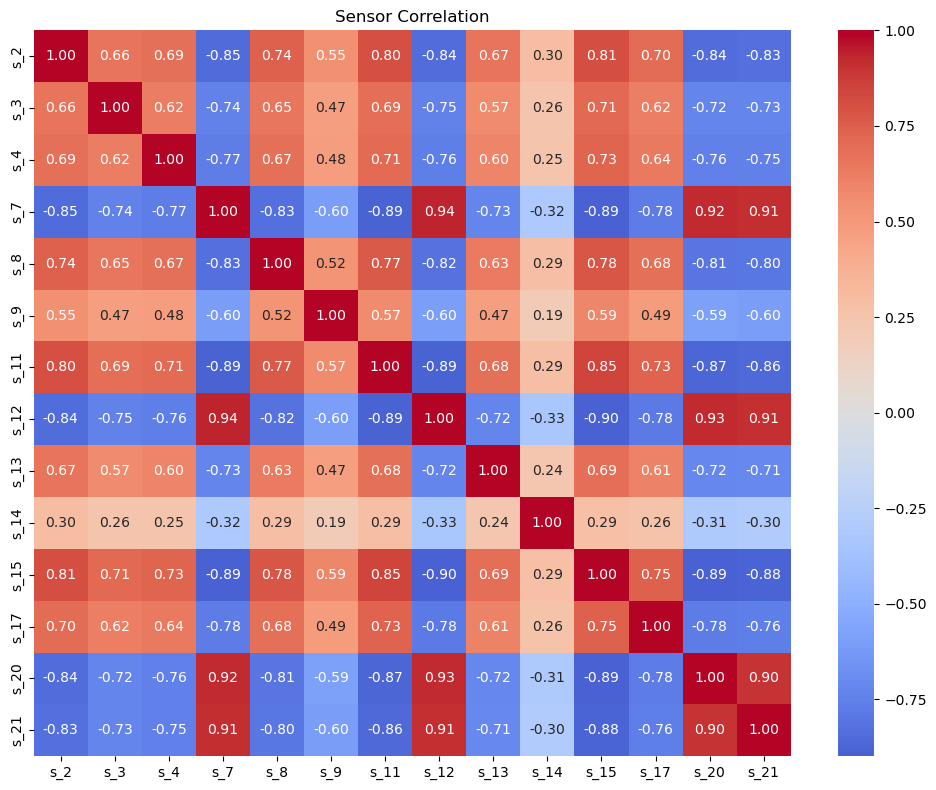

In [65]:
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Sensor Correlation')
plt.tight_layout()
plt.show()

In [66]:
e2 = df[df['unit_nr'] ==  2].sort_values('time_cycles').reset_index(drop=True)

e2['5ma_s_11'] = e2['s_11'].rolling(window=5).mean()
e2['5ma_s_12'] = e2['s_12'].rolling(window=5).mean()
e2['5ma_s_3'] = e2['s_3'].rolling(window=5).mean()

e2['5std_s_11'] = e2['s_11'].rolling(window=5).std()
e2['5std_s_12'] = e2['s_12'].rolling(window=5).std()
e2['5std_s_3'] = e2['s_3'].rolling(window=5).std()

ma5 = ['5ma_s_11', '5ma_s_12', '5ma_s_3']
std5 = ['5std_s_11', '5std_s_12', '5std_s_3']

for i in ma5:
    val = e2[i].dropna()

    first = val.iloc[0]
    last = val.iloc[-1]

    if first > last:
        result = '하강'

    elif first < last:
        result = '상승'

    else:
        result = '변화 없음'

    print(i, result)

for i in std5:
    val = e2[i].dropna()

    first = val.iloc[0]
    last = val.iloc[-1]

    if first > last:
        result = '하강'

    elif first < last:
        result = '상승'

    else:
        result = '변화 없음'

    print(i, result)

5ma_s_11 상승
5ma_s_12 하강
5ma_s_3 상승
5std_s_11 상승
5std_s_12 하강
5std_s_3 상승


In [67]:
report_df = e2.copy()
report_df['std5'] = e2['s_11'].rolling(window=5).std()
treshold = report_df['std5'].mean()+report_df['std5'].std()

suspect = report_df[report_df['std5'] > treshold]

print(f"의심 cycle 개수: {len(suspect)}, 범위: {suspect['time_cycles'].min()} ~ {suspect['time_cycles'].max()}")
print(f'[리포트] 엔진 2, 전체 cycle 수:{len(report_df)}, 의심 개수: {len(suspect)}, 권장행동 -> 의심 되는 곳 점검 ')

의심 cycle 개수: 38, 범위: 11 ~ 283
[리포트] 엔진 2, 전체 cycle 수:287, 의심 개수: 38, 권장행동 -> 의심 되는 곳 점검 


In [68]:
#제철소 데이터 실습

In [69]:
print(df_range.columns)

Index(['MTR02_TEMP', 'MTR02_TEMP_B', 'MTR02_VIB_H', 'MTR02_CURRENT',
       'MTR02_RUN', 'HYD02_PRESS', 'HYD02_PRESS_ACC', 'HYD02_FLOW',
       'FUR02_TEMP_Z1', 'MTR02_TEMP_diff', 'MTR02_TEMP_B_diff',
       'MTR02_VIB_H_diff', 'MTR02_CURRENT_diff', 'MTR02_RUN_diff',
       'HYD02_PRESS_diff', 'HYD02_PRESS_ACC_diff', 'HYD02_FLOW_diff',
       'FUR02_TEMP_Z1_diff'],
      dtype='object')


In [71]:
df_range.index = pd.to_datetime(df_range.index)
df_range = df_range.sort_index()

df_ahlam['event_time'] = pd.to_datetime(df_ahlam['event_time'])
df_ahlam = df_ahlam.sort_values('event_time')

sensors = ['MTR02_TEMP', 'MTR02_TEMP_B', 'MTR02_VIB_H', 'MTR02_CURRENT',
           'MTR02_RUN', 'HYD02_PRESS', 'HYD02_PRESS_ACC', 'HYD02_FLOW',
           'FUR02_TEMP_Z1']

k = 3
time_window = pd.Timedelta('30min')

for i in sensors:
    diff_col = i + '_diff'
    df_range[diff_col] = df_range[i].diff().abs()

    threshold = df_range[diff_col].mean() + k * df_range[diff_col].std()
    suspect_idx = df_range[df_range[diff_col] > threshold].index

    print(f'\n[{i}]')
    print('threshold:', threshold)
    print('이상의심 구간 개수:', len(suspect_idx))

    for idx in suspect_idx:
        pos = df_range.index.get_loc(idx)

        if pos == 0:
            continue

        prev_time = df_range.index[pos - 1]
        curr_time = idx

        prev_value = df_range[i].iloc[pos - 1]
        curr_value = df_range[i].iloc[pos]
        diff_value = df_range[diff_col].iloc[pos]

        near_events = df_ahlam[
            (df_ahlam['event_time'] >= curr_time - time_window) &
            (df_ahlam['event_time'] <= curr_time + time_window)
        ]

        same_tag_events = near_events[near_events['tag'] == i]

        if len(same_tag_events) > 0:
            event = same_tag_events.iloc[0]
            event_type = event['event_type']
            description = event['description']

            if event_type == '설비정지':
                category = '조업 정지 또는 운전 중단 영향'
            elif event_type == '통신장애':
                category = '통신 장애 또는 데이터 수집 문제'
            elif event_type in ['교정', '센서교체']:
                category = '센서 드리프트 또는 계측 이상'
            elif event_type == '알람':
                category = '실제 설비 이상'
            else:
                category = '판단 보류'

            evidence = f'동일 태그 이벤트: {event_type}, {description}'

        elif len(near_events) > 0:
            event = near_events.iloc[0]
            category = '판단 보류'
            evidence = f'근처 다른 태그 이벤트: {event["tag"]}, {event["event_type"]}, {event["description"]}'

        else:
            category = '이벤트 기록 없음'
            evidence = '전후 30분 내 관련 이벤트 없음'

        print('구간:', prev_time, '~', curr_time)
        print('값 변화:', prev_value, '->', curr_value)
        print('변화량:', diff_value)
        print('판단:', category)
        print('근거:', evidence)
        print()


[MTR02_TEMP]
threshold: 2.36860836457827
이상의심 구간 개수: 1
구간: 2026-04-01 20:50:00 ~ 2026-04-01 21:00:00
값 변화: 44.5 -> 55.0
변화량: 10.5
판단: 판단 보류
근거: 근처 다른 태그 이벤트: MTR02_RUN, 설비정지, 정지 해제 - 운전 재개


[MTR02_TEMP_B]
threshold: 2.348062090495534
이상의심 구간 개수: 1
구간: 2026-04-01 20:50:00 ~ 2026-04-01 21:00:00
값 변화: 43.0 -> 53.5
변화량: 10.5
판단: 판단 보류
근거: 근처 다른 태그 이벤트: MTR02_RUN, 설비정지, 정지 해제 - 운전 재개


[MTR02_VIB_H]
threshold: 0.6883554379826882
이상의심 구간 개수: 2
구간: 2026-04-01 17:50:00 ~ 2026-04-01 18:00:00
값 변화: 1.8 -> 0.0
변화량: 1.8
판단: 판단 보류
근거: 근처 다른 태그 이벤트: MTR02_RUN, 설비정지, 계획 정지 - 소재 교체 작업

구간: 2026-04-01 20:50:00 ~ 2026-04-01 21:00:00
값 변화: 0.0 -> 1.9
변화량: 1.9
판단: 판단 보류
근거: 근처 다른 태그 이벤트: MTR02_RUN, 설비정지, 정지 해제 - 운전 재개


[MTR02_CURRENT]
threshold: 16.96416312627096
이상의심 구간 개수: 2
구간: 2026-04-01 17:50:00 ~ 2026-04-01 18:00:00
값 변화: 62.0 -> 0.0
변화량: 62.0
판단: 판단 보류
근거: 근처 다른 태그 이벤트: MTR02_RUN, 설비정지, 계획 정지 - 소재 교체 작업

구간: 2026-04-01 20:50:00 ~ 2026-04-01 21:00:00
값 변화: 0.0 -> 63.0
변화량: 63.0
판단: 판단 보류
근거: 근처 다

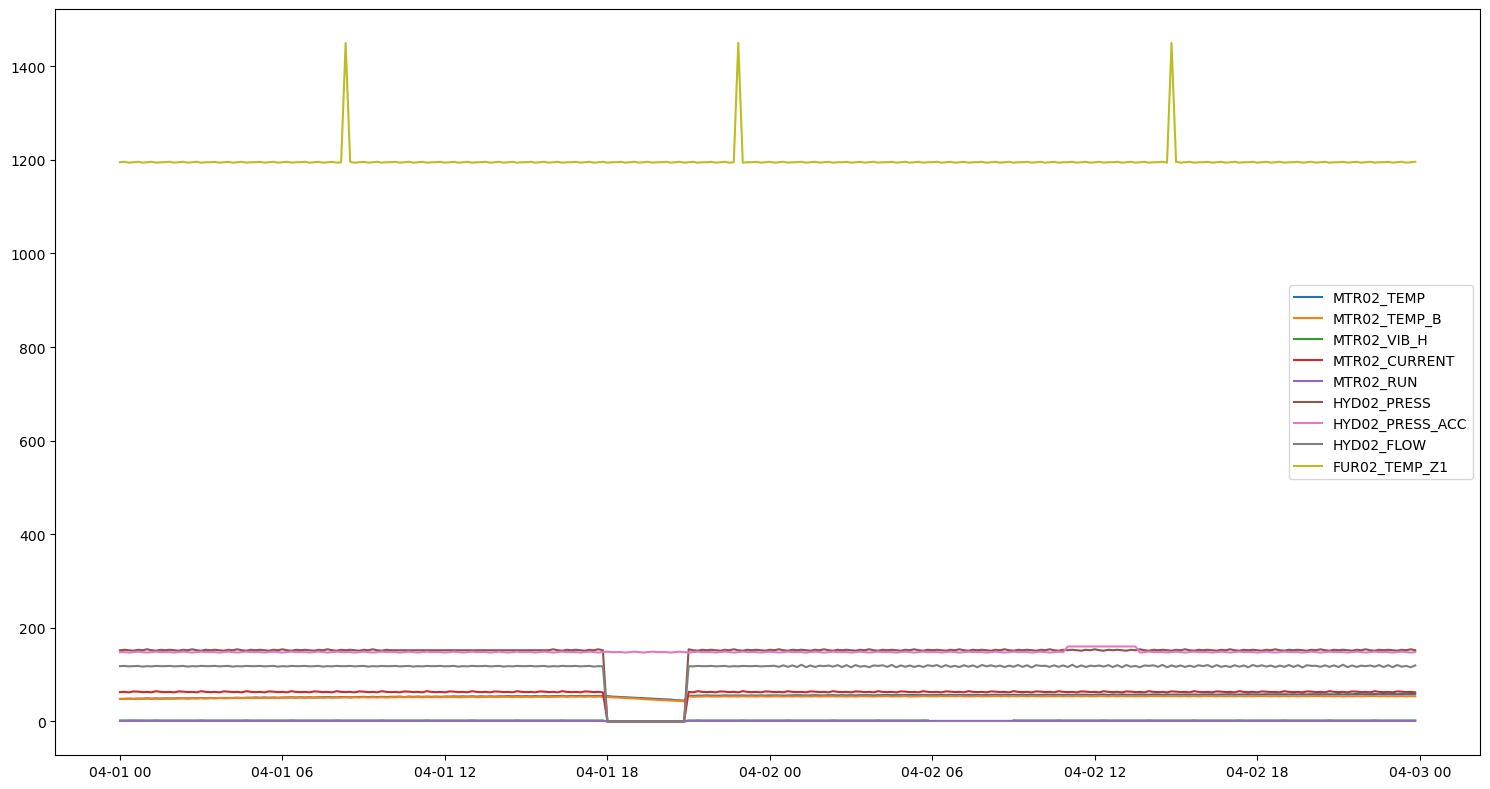

MTR02_TEMP 이상의심 구간 개수: 0
구간: 2026-04-01 20:50:00 ~ 2026-04-01 21:00:00
값 변화: 44.5 -> 55.0
변화량: 10.5
MTR02_TEMP_B 이상의심 구간 개수: 0
구간: 2026-04-01 20:50:00 ~ 2026-04-01 21:00:00
값 변화: 43.0 -> 53.5
변화량: 10.5
MTR02_VIB_H 이상의심 구간 개수: 1
구간: 2026-04-01 17:50:00 ~ 2026-04-01 18:00:00
값 변화: 1.8 -> 0.0
변화량: 1.8
구간: 2026-04-01 20:50:00 ~ 2026-04-01 21:00:00
값 변화: 0.0 -> 1.9
변화량: 1.9
MTR02_CURRENT 이상의심 구간 개수: 1
구간: 2026-04-01 17:50:00 ~ 2026-04-01 18:00:00
값 변화: 62.0 -> 0.0
변화량: 62.0
구간: 2026-04-01 20:50:00 ~ 2026-04-01 21:00:00
값 변화: 0.0 -> 63.0
변화량: 63.0
MTR02_RUN 이상의심 구간 개수: 1
구간: 2026-04-01 17:50:00 ~ 2026-04-01 18:00:00
값 변화: 1 -> 0
변화량: 1.0
구간: 2026-04-01 20:50:00 ~ 2026-04-01 21:00:00
값 변화: 0 -> 1
변화량: 1.0
HYD02_PRESS 이상의심 구간 개수: 1
구간: 2026-04-01 17:50:00 ~ 2026-04-01 18:00:00
값 변화: 152.0 -> 0.0
변화량: 152.0
구간: 2026-04-01 20:50:00 ~ 2026-04-01 21:00:00
값 변화: 0.0 -> 154.0
변화량: 154.0
HYD02_PRESS_ACC 이상의심 구간 개수: 1
구간: 2026-04-02 10:50:00 ~ 2026-04-02 11:00:00
값 변화: 148.0 -> 160.0
변화량: 12.0
구간: 202

In [ ]:
df_range = pd.read_csv('02-04_센서_고장_판별_이상구간샘플_210_260901_Question_2.csv')
df_ahlam = pd.read_csv('02-04_센서_고장_판별_정비알람이력_210_260901_Question_3.csv')

# 1.센서데이터를 시간순으로 정렬
df_range['timestamp'] = pd.to_datetime(df_range['timestamp'])
df_range = df_range.set_index('timestamp').sort_index()

# 2.주요 센서 그래프 확인

sensors = ['MTR02_TEMP', 'MTR02_TEMP_B', 'MTR02_VIB_H', 'MTR02_CURRENT',
       'MTR02_RUN', 'HYD02_PRESS', 'HYD02_PRESS_ACC', 'HYD02_FLOW',
       'FUR02_TEMP_Z1']

plt.figure(figsize=(15,8))

for i in sensors:
    plt.plot(df_range.index, df_range[i], label=i)

plt.legend()
plt.tight_layout()
plt.show()


# 이상하거나 특이한 시간 구간을 찾는다


k=3
for i in sensors:
    diff_col = i + '_diff'
    df_range[diff_col] = df_range[i].diff().abs()

    treshold = df_range[diff_col].mean()+k*df_range[diff_col].std()

    suspect_idx = df_range[df_range[diff_col] > treshold].index
    print(i,"이상의심 구간 개수:",len(suspect_idx)//2 )

    for idx in suspect_idx:
        pos = df_range.index.get_loc(idx)

        if pos == 0:
            continue

        prev_time = df_range.index[pos - 1]
        curr_time = idx

        prev_value = df_range[i].iloc[pos - 1]
        curr_value = df_range[i].iloc[pos]
        diff_value = df_range[diff_col].iloc[pos]

        print("구간:", prev_time, "~", curr_time)
        print("값 변화:", prev_value, "->", curr_value)
        print("변화량:", diff_value)


# 04-01 18시부터 04-01 21시 = 이상구간
# 이유: '02-04_센서_고장_판별_정비알람이력_210_260901_Question_3' 문서에 정지라고 나와있고 + 그래프를 그렸을때 수치가 몇개 센서 제외 0을 향하는것을 볼 수 있다

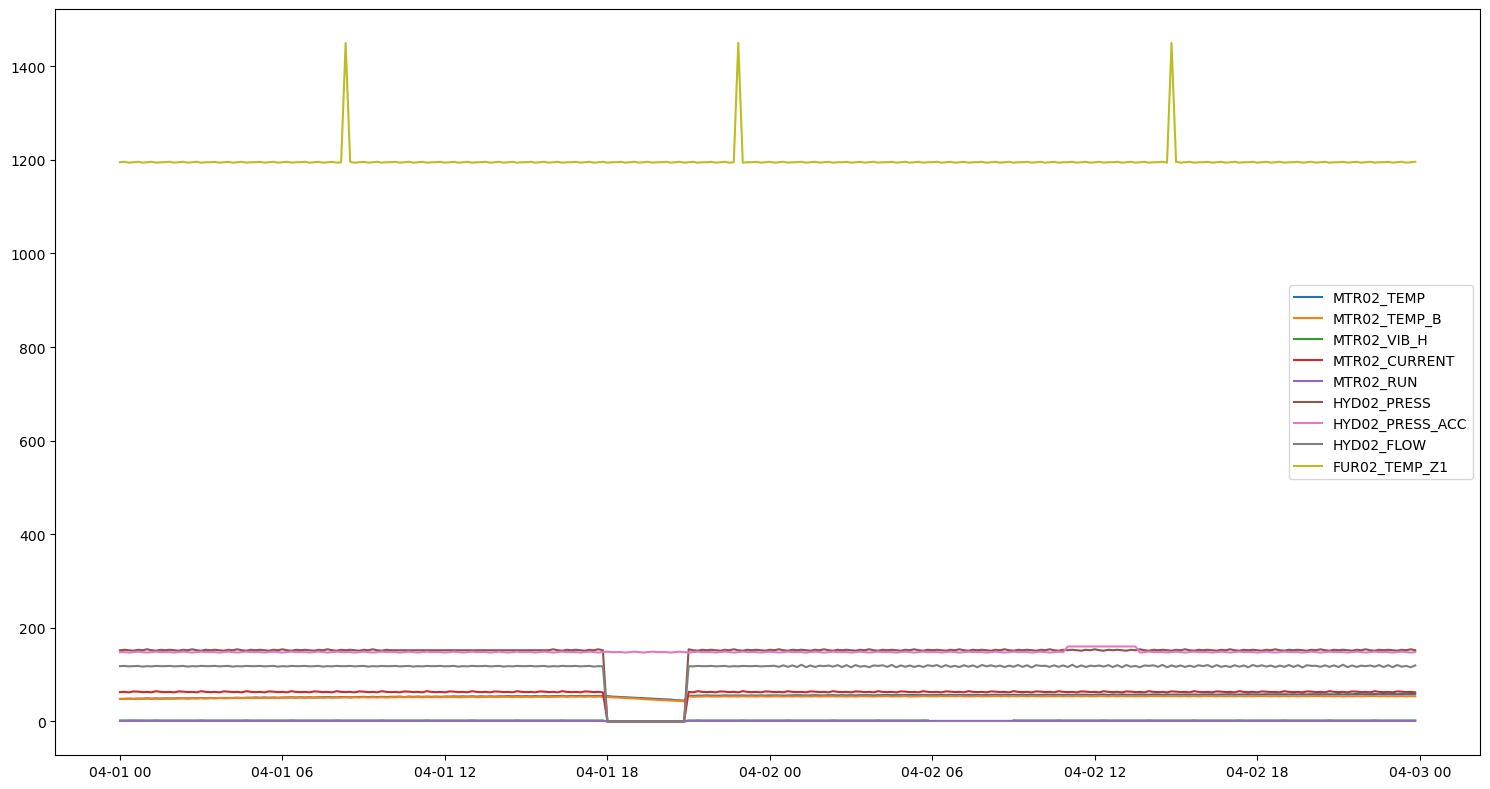

In [75]:
sensors = ['MTR02_TEMP', 'MTR02_TEMP_B', 'MTR02_VIB_H', 'MTR02_CURRENT',
       'MTR02_RUN', 'HYD02_PRESS', 'HYD02_PRESS_ACC', 'HYD02_FLOW',
       'FUR02_TEMP_Z1']

plt.figure(figsize=(15,8))

for i in sensors:
    plt.plot(df_range.index, df_range[i], label=i)

plt.legend()
plt.tight_layout()
plt.show()